<a href="https://colab.research.google.com/github/DhiegoIsmael/Atividade-matematica-aplicada/blob/main/Teste1_Fundamentos_Matematicos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Teste 1 – Fundamentos Matemáticos
### Análise e previsão dos custos de transporte de uma empresa de e-commerce

**Objetivo:** utilizar conceitos de funções (função afim) para analisar os dados históricos de custo de transporte, representar graficamente o comportamento dos custos e realizar uma previsão para os próximos meses.

## Etapa 1 – Carregar os dados

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregando a base de dados
df = pd.read_csv("base_custos_transporte.csv")
df

,mes,custo_transporte
0,1,44500
1,2,45200
2,3,48300
3,4,48600
4,5,51300
5,6,53300
6,7,53800
7,8,57000
8,9,57900
9,10,61000


## Etapa 2 – Identificar as variáveis

A base possui duas variáveis: **mes** e **custo_transporte**.

**a) Qual é a variável independente?**
A variável independente é o **mês (mes)**, pois representa o tempo, que avança de forma autônoma, sem depender de nenhuma outra grandeza da base.

**b) Qual é a variável dependente?**
A variável dependente é o **custo de transporte (custo_transporte)**, pois seu valor varia em função do mês observado.

**c) O que representa cada variável no contexto do problema?**
- `mes`: indica o número do mês em que os custos foram registrados (de 1 a 12), representando a evolução do tempo.
- `custo_transporte`: representa o valor total, em reais, gasto pela empresa com transporte naquele mês.

## Etapa 3 – Construir um gráfico

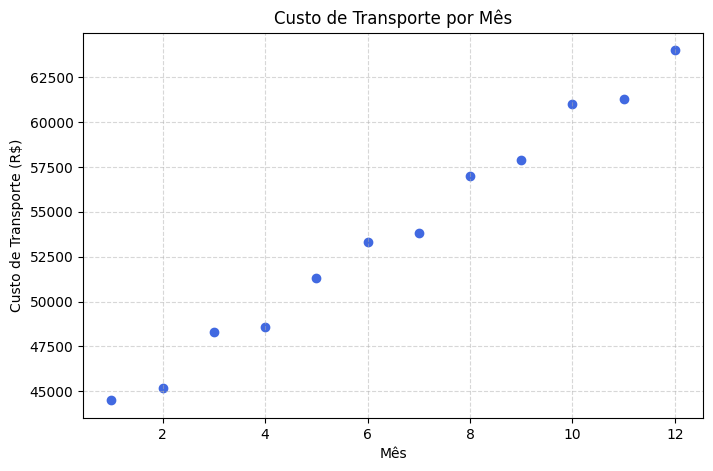

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(df["mes"], df["custo_transporte"], color="royalblue")
plt.title("Custo de Transporte por Mês")
plt.xlabel("Mês")
plt.ylabel("Custo de Transporte (R$)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

**Comportamento observado:** os pontos mostram uma tendência clara de **crescimento** dos custos de transporte ao longo dos meses. O aumento parece ocorrer de forma aproximadamente constante mês a mês, sugerindo que uma **função afim (linear)** pode representar bem esse comportamento.

## Etapa 4 – Encontrar uma função

Vamos considerar uma função afim da forma:

$$f(x) = ax + b$$

Os coeficientes `a` (inclinação) e `b` (valor inicial) serão calculados pelo método dos **mínimos quadrados**, usando apenas somatórios (sem uso de matrizes/álgebra linear):

$$a = \frac{n\sum{xy} - \sum{x}\sum{y}}{n\sum{x^2} - (\sum{x})^2} \qquad\qquad b = \bar{y} - a\bar{x}$$

In [4]:
x = df["mes"]
y = df["custo_transporte"]
n = len(x)

soma_x = x.sum()
soma_y = y.sum()
soma_xy = (x * y).sum()
soma_x2 = (x ** 2).sum()

a = (n * soma_xy - soma_x * soma_y) / (n * soma_x2 - soma_x**2)
b = (soma_y / n) - a * (soma_x / n)

print(f"a = {a:.4f}")
print(f"b = {b:.4f}")
print(f"Função encontrada: f(x) = {a:.2f}x + {b:.2f}")

a = 1791.6084
b = 42204.5455
Função encontrada: f(x) = 1791.61x + 42204.55


**Resultado:**
- a ≈ **1791,61**
- b ≈ **42204,55**
- Função encontrada: **f(x) = 1791,61x + 42204,55**

## Etapa 5 – Interpretar a função

**a) O que representa o coeficiente `a` no contexto do problema?**
O coeficiente `a` representa a **taxa de variação mensal** do custo de transporte, ou seja, o quanto o custo aumenta (em reais) a cada mês que passa. Aqui, `a ≈ 1791,61`, o que significa que o custo de transporte cresce em média R$ 1.791,61 por mês.

**b) O que representa o coeficiente `b`?**
O coeficiente `b` representa o **custo estimado no mês 0** (ponto em que a reta cruza o eixo y), ou seja, um valor de referência/base do custo de transporte antes do início da série observada. Aqui, `b ≈ 42204,55`.

**c) O valor de `a` indica crescimento ou redução dos custos?**
Como `a` é **positivo**, ele indica **crescimento** dos custos de transporte ao longo do tempo.

## Etapa 6 – Representar a função graficamente

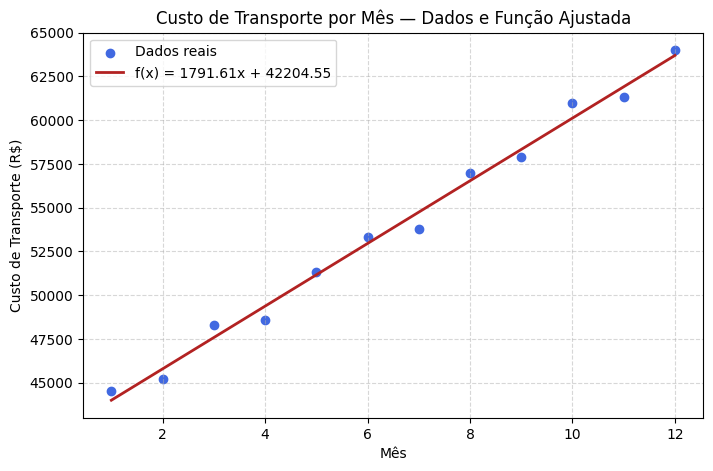

In [5]:
y_pred = a * x + b

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color="royalblue", label="Dados reais")
plt.plot(x, y_pred, color="firebrick", linewidth=2, label=f"f(x) = {a:.2f}x + {b:.2f}")
plt.title("Custo de Transporte por Mês — Dados e Função Ajustada")
plt.xlabel("Mês")
plt.ylabel("Custo de Transporte (R$)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## Etapa 7 – Fazer previsões

In [6]:
for mes_futuro in [13, 14, 15]:
    custo_estimado = a * mes_futuro + b
    print(f"Mês {mes_futuro}: custo estimado = R$ {custo_estimado:,.2f}")

Mês 13: custo estimado = R$ 65,495.45
Mês 14: custo estimado = R$ 67,287.06
Mês 15: custo estimado = R$ 69,078.67


**Cálculos realizados:**
- f(13) = 1791,61 × 13 + 42204,55 = **R$ 65.495,45**
- f(14) = 1791,61 × 14 + 42204,55 = **R$ 67.287,06**
- f(15) = 1791,61 × 15 + 42204,55 = **R$ 69.078,67**

## Etapa 8 – Analisar o resultado

**a) A função encontrada representa bem a tendência dos dados?**
Sim. Ao comparar os valores estimados pela reta com os dados observados (especialmente nos últimos meses, como o mês 12, onde o custo real foi R$ 64.000 e a função estima aproximadamente R$ 65.495 no mês 13), percebe-se que a reta acompanha de perto o crescimento real da série, com pequenos desvios — típicos de um ajuste linear simples.

**b) Os custos estão aumentando ou diminuindo?**
Os custos estão **aumentando** de forma consistente ao longo dos meses.

**c) Aproximadamente quanto o custo aumenta a cada mês?**
O custo aumenta, em média, aproximadamente **R$ 1.791,61 por mês**, valor que corresponde ao coeficiente `a` da função encontrada.

## Etapa 9 – Conclusão

Com base na análise dos dados históricos, observa-se que os custos de transporte da empresa apresentam uma **tendência clara e consistente de crescimento** ao longo do tempo, aumentando em média R$ 1.791,61 a cada mês. A função afim `f(x) = 1791,61x + 42204,55` se ajusta bem ao comportamento observado nos 12 meses analisados.

Caso essa tendência se mantenha, a empresa deve **esperar que os custos de transporte continuem subindo** nos próximos meses, alcançando aproximadamente R$ 65.495,45 no mês 13, R$ 67.287,06 no mês 14 e R$ 69.078,67 no mês 15. Esse cenário sugere que a empresa deve **planejar seu orçamento com essa tendência de alta em mente**, além de avaliar possíveis causas do aumento (como custos de combustível, distância ou volume de entregas) e buscar estratégias de otimização logística para conter esse crescimento.